In [1]:
import pandas

# read from train.csv
fulldf = pandas.read_csv('train.csv')

/var/folders/x_/rd78sz7s181dgnvygzmgz0b40000gn/T/ipykernel_67767/245758509.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  fulldf = pandas.read_csv('train.csv')


In [2]:
fulldf

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


# Scope Selection

It would be very computational heavy to process all 100,000 time series with a single MacBook and limited time of the take-home assignment. We will choose to to solve only a subset of the problem.

There is a hierarchy in this problem, for exmaple, there are many time series under the same item, same item class. There are 2 approaches to tackle the problem
- Top-down approach: this will let us study the relationship between factors in the hierachy at the high level. It also allow 
- Bottom-up approach: this will let us study deeply how to handle issues in a case-by-case basis. if we need to process 100,000 time series, we and iterate automatically later.

We will choose the bottom up approach in this notebook for ease of computing and to show to handle issues deeply

In [3]:
fulldf.set_index(['item_nbr', 'store_nbr'], inplace=True)

(                   id  unit_sales onpromotion
 date                                         
 2014-04-01   21700431        15.0       False
 2014-04-02   21751452        15.0       False
 2014-04-03   21801416         9.0       False
 2014-04-04   21851328        13.0       False
 2014-04-05   21904338        37.0       False
 ...               ...         ...         ...
 2017-08-11  125058830        24.0       False
 2017-08-12  125164123        17.0       False
 2017-08-13  125269808        21.0       False
 2017-08-14  125373927        16.0       False
 2017-08-15  125476811         8.0       False
 
 [1227 rows x 3 columns],
 (1227, 3))

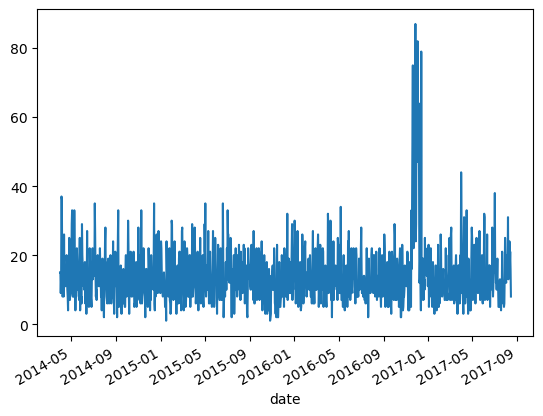

In [4]:
# idx = (df.index.get_level_values('item_nbr') == 103665) & (df.index.get_level_values('store_nbr') == 25) # hard
idx = (fulldf.index.get_level_values('item_nbr') == 313641) & (fulldf.index.get_level_values('store_nbr') == 46)
idx = idx & ((fulldf.onpromotion == False) | (fulldf.onpromotion == True))

sampledf = fulldf.loc[idx, ].copy()
sampledf.set_index('date', inplace=True)
# the index is str now. make it date
sampledf.index = pandas.to_datetime(sampledf.index)

# cast unit_sales to float
sampledf.unit_sales = sampledf.unit_sales.astype(float)

# filter on upto 2016
# sampledf = sampledf.loc[sampledf.index < '2017-01-01', ].copy()

# plot
sampledf.unit_sales.plot()

sampledf, sampledf.shape

In [5]:
sampledf.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1227 entries, 2014-04-01 to 2017-08-15
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1227 non-null   int64  
 1   unit_sales   1227 non-null   float64
 2   onpromotion  1227 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 38.3+ KB


In [6]:
sampledf.sort_index(inplace=True)

# Start Filling Date Gap

In [7]:
# check date gaps
# add a column days since last
sampledf['date_jump'] = sampledf.index.to_series().diff().dt.days - 1
sampledf.date_jump.value_counts()

date_jump
0.0    1220
1.0       6
Name: count, dtype: int64

In [8]:


# group by year month then sum date_jump. show only the ones with date_jump > 0
print(sampledf.groupby([sampledf.index.year, sampledf.index.month]).date_jump.sum().loc[lambda x: x > 0])

# also sum all date_jump in the dataset and calculate % to total rows
print('date gap count', sampledf.date_jump.sum(), sampledf.date_jump.sum() / sampledf.shape[0], '%')

date  date
2014  12      1.0
2015  1       1.0
      12      1.0
2016  1       1.0
      12      1.0
2017  1       1.0
Name: date_jump, dtype: float64
date gap count 6.0 0.004889975550122249 %


In [9]:
# add column unit_sales moving average 7 days, not include today (i.e. lag 1)
sampledf['unit_sales_ma7_lag1'] = sampledf.unit_sales.rolling(window=7).mean().shift(1)
sampledf['unit_sales_ma30_lag1'] = sampledf.unit_sales.rolling(window=30).mean().shift(1)

In [10]:
# count different values of onpromotion
sampledf.groupby('onpromotion').size()

onpromotion
False    1205
True       22
dtype: int64

In [11]:
# create series of all dates between min and max date
date_range = pandas.date_range(sampledf.index.min(), sampledf.index.max())
# filter only dates that are not in the original dataset
missing_dates = date_range.difference(sampledf.index)

# create a new dataframe. index = date. onpromotion = False. unit_sales = unit_sales_ma7_lag1 from the date closest before
missingdf = pandas.DataFrame(index=missing_dates)
missingdf['onpromotion'] = False
# create unit_sales column by finding the closest date before in the original dataset
missingdf['unit_sales'] = 0.0
for date in missingdf.index:
    closest_date = sampledf.index[sampledf.index <= date].max()
    missingdf.loc[date, 'unit_sales'] = sampledf.loc[closest_date, 'unit_sales']

# append missingdf to sampledf
# don't use df.append method because AttributeError: 'DataFrame' object has no attribute 'append'

sampledf = pandas.concat([sampledf, missingdf], sort=True)
sampledf.sort_index(inplace=True)


In [12]:
# check date gaps
# add a column days since last
sampledf['date_jump'] = sampledf.index.to_series().diff().dt.days - 1
sampledf.date_jump.value_counts()

date_jump
0.0    1232
Name: count, dtype: int64

<Axes: >

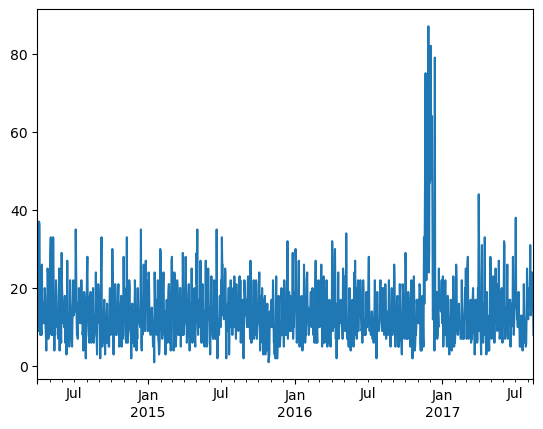

In [13]:
sampledf.unit_sales.plot()

In [14]:
# filter sampledf to only up to 2016-06-01
# sampledf = sampledf.loc[sampledf.index < '2016-01-01', ].copy()
# sampledf.unit_sales.plot()

# Date Gaps are filled

# Oil

In [15]:
# load oil.csv
oil = pandas.read_csv('oil.csv')
oil.date = pandas.to_datetime(oil.date)
oil.set_index('date', inplace=True)
oil.sort_index(inplace=True)

In [16]:
# check missing values in oil
oil.isnull().sum()

dcoilwtico    43
dtype: int64

<Axes: xlabel='date'>

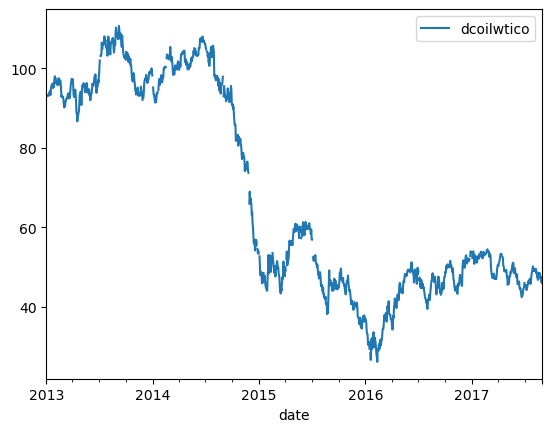

In [17]:
oil.plot()

In [18]:
# fill missing dcoilwtico with previous value
# oil.dcoilwtico.fillna(method='ffill', inplace=True)

mindate = min(sampledf.index.min(), oil.index.min())
maxdate = max(sampledf.index.max(), oil.index.max())
alldates = pandas.date_range(mindate, maxdate)
# all dates not in oil
missingdates = alldates.difference(oil.index)

# create a new dataframe. index = date. dcoilwtico = dcoilwtico from the date closest before
missingdf = pandas.DataFrame(index=missingdates)
missingdf['dcoilwtico'] = None

# concat back to oil
oil2 = pandas.concat([oil, missingdf], sort=True)
oil2.sort_index(inplace=True)
oil2.dcoilwtico.fillna(method='ffill', inplace=True)
oil2.dcoilwtico.fillna(method='bfill', inplace=True)

/var/folders/x_/rd78sz7s181dgnvygzmgz0b40000gn/T/ipykernel_67767/2632610076.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  oil2 = pandas.concat([oil, missingdf], sort=True)
/var/folders/x_/rd78sz7s181dgnvygzmgz0b40000gn/T/ipykernel_67767/2632610076.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on

<Axes: >

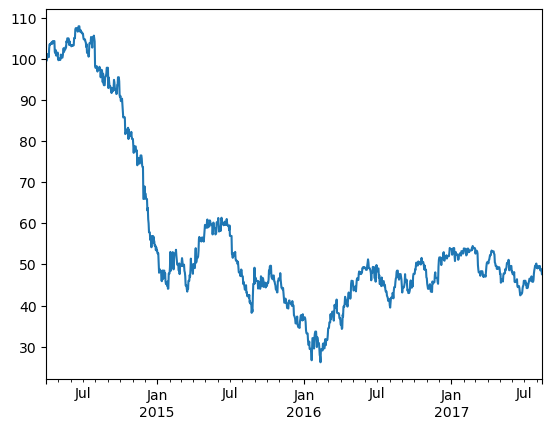

In [19]:
# merge oil2 to sampledf
sampledf = sampledf.join(oil2, how='left')
sampledf.dcoilwtico.plot()

In [20]:
sampledf.loc['2016-12-25']

date_jump                 0.0
id                        NaN
onpromotion             False
unit_sales               15.0
unit_sales_ma30_lag1      NaN
unit_sales_ma7_lag1       NaN
dcoilwtico              52.01
Name: 2016-12-25 00:00:00, dtype: object

# Enrich other fields

In [21]:
# add column unit_sales moving average 7 days, not include today (i.e. lag 1)
sampledf['unit_sales_ma7_lag1'] = sampledf.unit_sales.rolling(window=7).mean().shift(1)
sampledf['unit_sales_ma30_lag1'] = sampledf.unit_sales.rolling(window=30).mean().shift(1)

In [22]:
# create column onpromotionnum if onpromotion is "True" then 1, "False" then -1, "NaN" then 0
import math
sampledf['onpromotionnum'] = sampledf['onpromotion'].map({True: 1, False: -1, math.nan: 0})

In [23]:
# feature engineering 1 and 0
# day of month
for i in range(1, 32):
    sampledf['dom' + str(i)] = (sampledf.index.day == i).astype(int)
# day of week

for i in range(7):
    sampledf['dow' + str(i)] = (sampledf.index.weekday == i).astype(int)


# month of year
for i in range(1, 13):
    sampledf['moy' + str(i)] = (sampledf.index.month == i).astype(int)


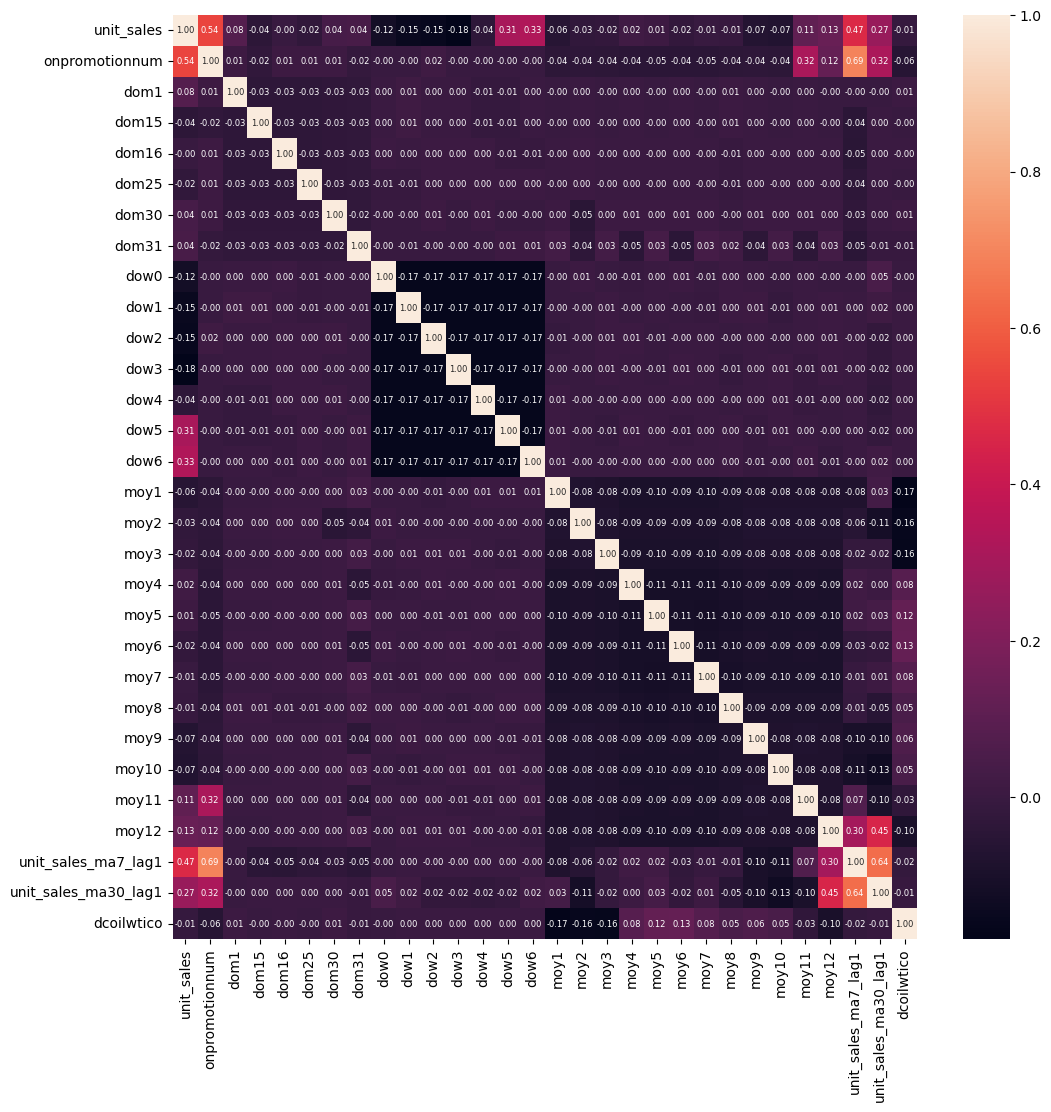

In [24]:
# do correlation cross matrix heat map
columns = [
    'unit_sales',
    'onpromotionnum',
    'dom1',
    # 'dom2', 'dom3', 'dom4', 'dom5', 'dom6', 'dom7', 'dom8', 'dom9', 'dom10',
    # 'dom11', 'dom12', 'dom13', 'dom14',
    'dom15', 'dom16',
    # 'dom17', 'dom18', 'dom19', 'dom20',
    # 'dom21', 'dom22', 'dom23', 'dom24',
    'dom25',
    # 'dom26', 'dom27', 'dom28', 'dom29',
    'dom30', 'dom31',
    'dow0', 'dow1', 'dow2', 'dow3', 'dow4', 'dow5', 'dow6',
    'moy1', 'moy2', 'moy3', 'moy4', 'moy5', 'moy6', 'moy7', 'moy8', 'moy9', 'moy10', 'moy11', 'moy12',

    'unit_sales_ma7_lag1',
    'unit_sales_ma30_lag1',

    'dcoilwtico'
]

corr = sampledf[columns].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, fmt=".2f", annot_kws={"size": 6})
plt.show()


<Axes: title={'center': 'unit_sales'}, xlabel='dow'>

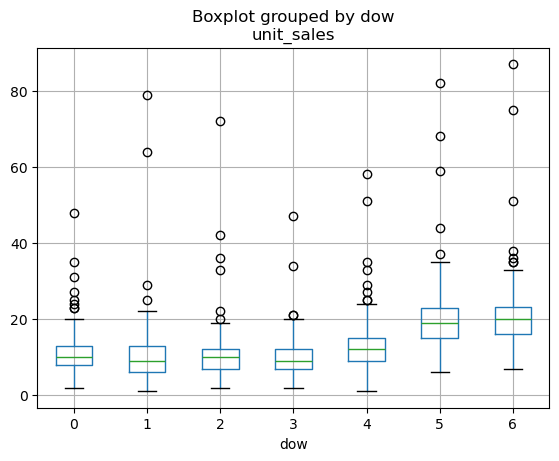

In [25]:
sampledf['dow'] = sampledf.index.weekday
# boxplot of unit_sales by dow
sampledf.boxplot(column='unit_sales', by='dow')

<Axes: title={'center': 'unit_sales'}, xlabel='[onpromotion]'>

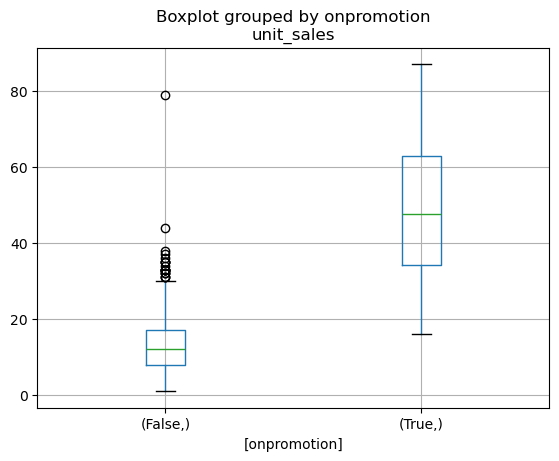

In [26]:
# boxplot of unit_sales by dow and onpromotion
sampledf.boxplot(column='unit_sales', by=[ 'onpromotion'])


<Axes: title={'center': 'unit_sales'}, xlabel='moy'>

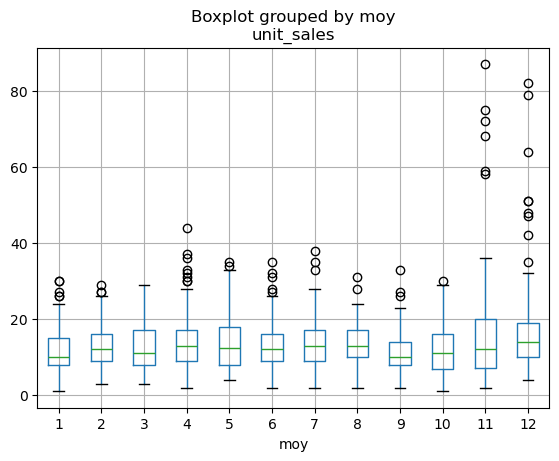

In [27]:
sampledf['moy'] = sampledf.index.month
# boxplot of unit_sales by dow
sampledf.boxplot(column='unit_sales', by='moy')

<Axes: xlabel='dcoilwtico', ylabel='unit_sales'>

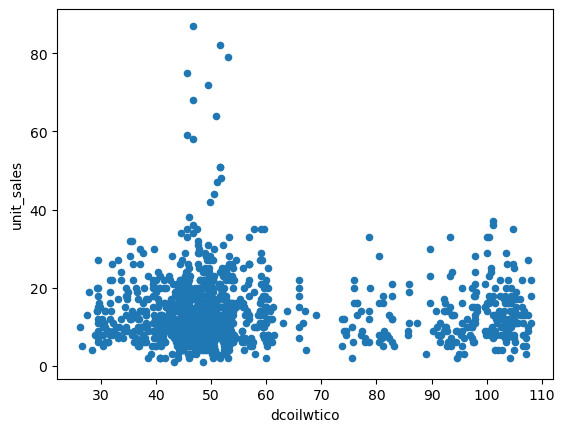

In [28]:
# scatter unit_sales vs dcoilwtico
sampledf.plot.scatter(x='dcoilwtico', y='unit_sales')


DatetimeIndex(['2016-11-16', '2016-11-18', '2016-11-19', '2016-11-20',
               '2016-11-21', '2016-11-23', '2016-11-24', '2016-11-25',
               '2016-11-26', '2016-11-27', '2016-11-30', '2016-12-01',
               '2016-12-02', '2016-12-03', '2016-12-04', '2016-12-05',
               '2016-12-06', '2016-12-07', '2016-12-13'],
              dtype='datetime64[ns]', freq=None)

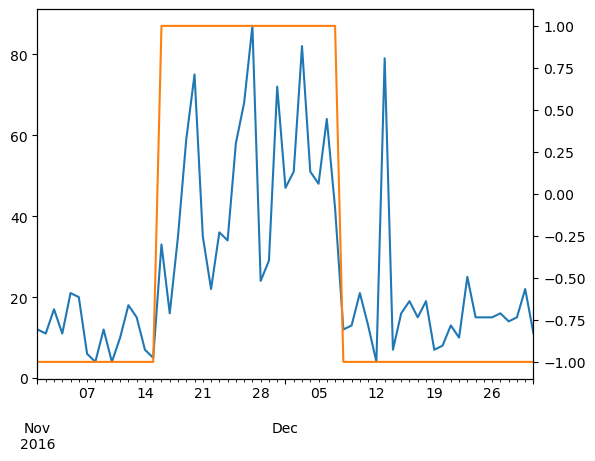

In [29]:
# sampledf during 2016-11 2016-12
sampledf['2016-11':'2016-12'].unit_sales.plot()
sampledf['2016-11':'2016-12'].onpromotionnum.plot(secondary_y=True)

# sampledf['2016-11':'2016-12'] where unit_sales > 30
sampledf['2016-11':'2016-12'].loc[sampledf.unit_sales > 30, ].index

In [30]:
sampledf['period'] = '1before'
sampledf.loc['2016-11-16':'2016-12-15', 'period'] = '3spike'
sampledf.loc['2016-12-16':, 'period'] = '4after'
sampledf.loc['2016-04-16':'2016-04-22', 'period'] = '2quake'

In [31]:
# compare the distribution of many columns in each period
compare_columns = [
    'unit_sales',
    'onpromotionnum',
    'dcoilwtico',
]
sampledf.groupby('period')[compare_columns].describe()

unit_sales                                                       \
             count       mean        std  min    25%   50%    75%   max   
period                                                                    
1before      953.0  13.067156   6.523527  1.0   8.00  12.0  17.00  37.0   
2quake         7.0  13.000000   5.507571  7.0  10.00  12.0  14.00  24.0   
3spike        30.0  41.100000  24.284733  4.0  21.25  35.5  58.75  87.0   
4after       243.0  13.419753   6.823993  3.0   8.50  12.0  17.00  44.0   

        onpromotionnum            ...           dcoilwtico             \
                 count      mean  ...  75%  max      count       mean   
period                            ...                                   
1before          953.0 -1.000000  ... -1.0 -1.0      953.0  58.924218   
2quake             7.0 -1.000000  ... -1.0 -1.0        7.0  41.440000   
3spike            30.0  0.466667  ...  1.0  1.0       30.0  48.974000   
4after           243.0 -1.000000  ... -1.0 -1.0      243.0  49.678765   

                                                        
               std    min    25%    50%    75%     max  
period                                                  
1before  23.112819  26.19  44.33  49.00  74.04  107.95  
2quake    1.400904  39.74  40.40  40.88  42.74   43.18  
3spike    2.691475  45.29  46.72  49.63  51.51   52.99  
4after    3.134765  42.48  47.30  49.58  52.54   54.48  

[4 rows x 24 columns]

<Axes: title={'center': 'unit_sales'}, xlabel='[period, onpromotionnum]'>

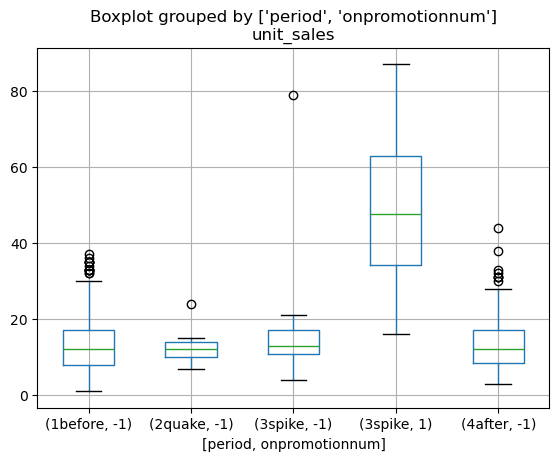

In [32]:
# boxplot of unit_sales by onpromotionnum and period
sampledf.boxplot(column='unit_sales', by=['period', 'onpromotionnum'])



<Axes: title={'center': 'dcoilwtico'}, xlabel='[period]'>

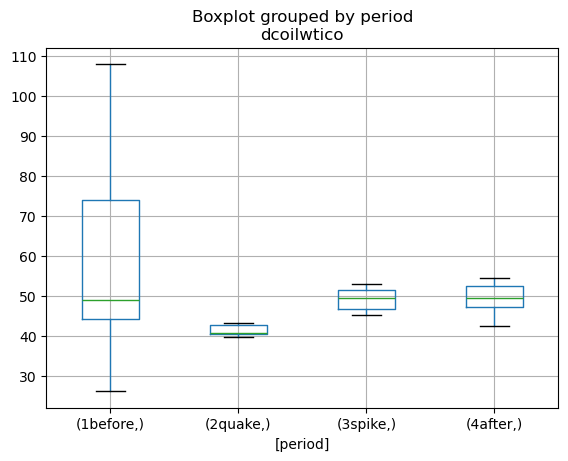

In [33]:
sampledf.boxplot(column='dcoilwtico', by=['period'])

<Axes: title={'center': 'onpromotionnum'}, xlabel='[period]'>

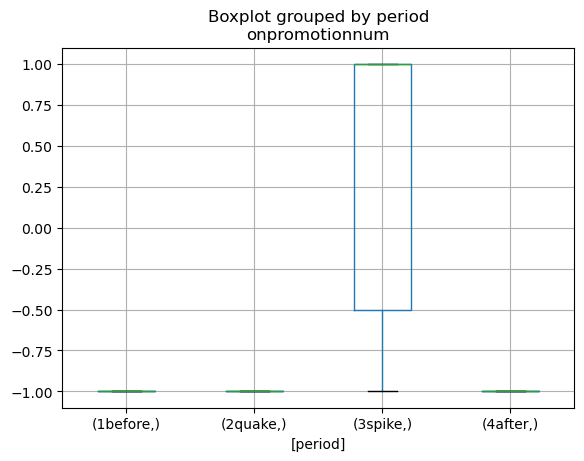

In [34]:
sampledf.boxplot(column='onpromotionnum', by=['period'])

<Axes: >

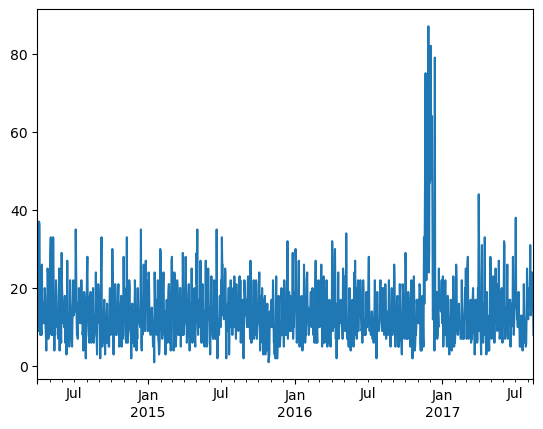

In [35]:
# plot samepledf

sampledf.unit_sales.plot()


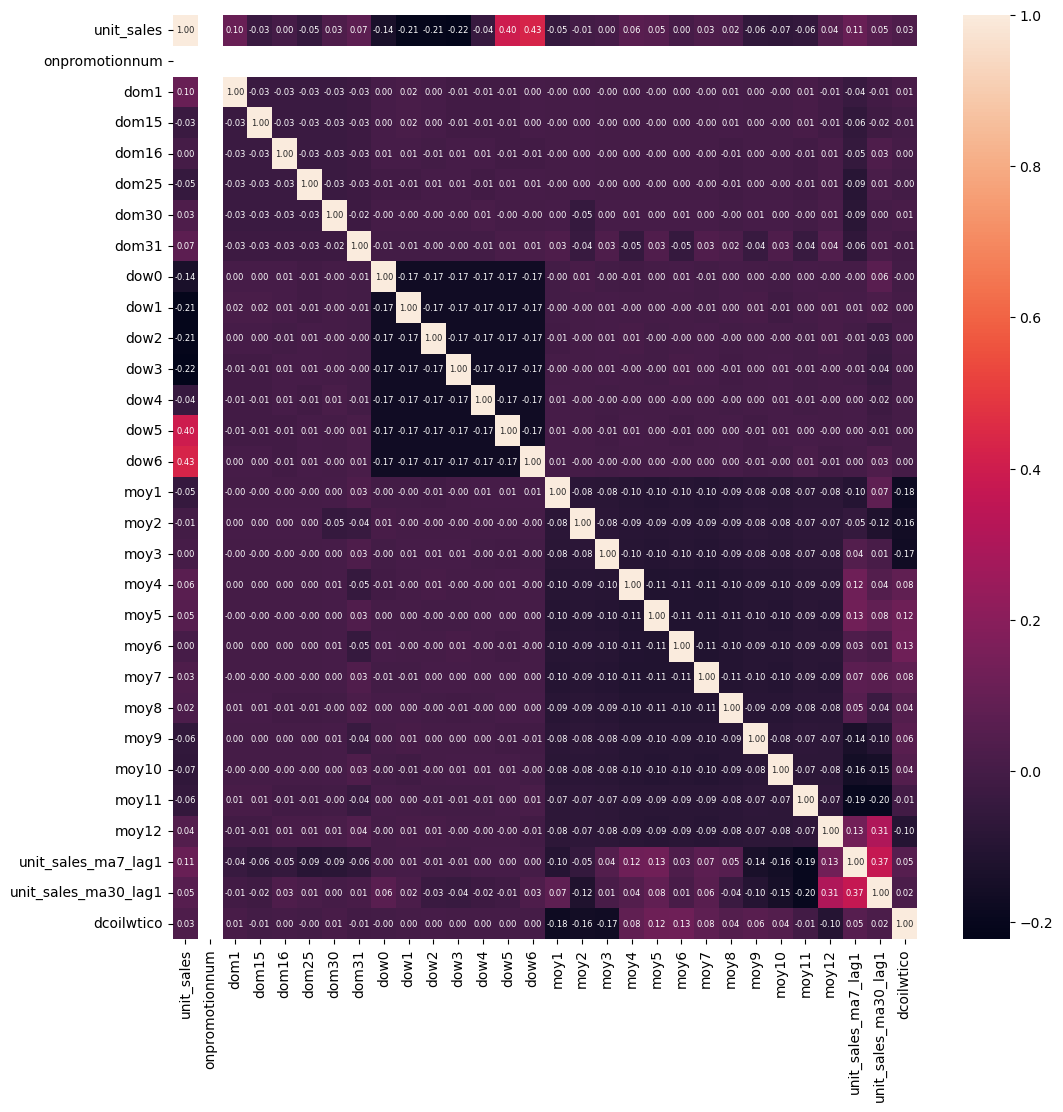

In [36]:
# do correlation cross matrix heat map
columns = [
    'unit_sales',
    'onpromotionnum',
    'dom1',
    # 'dom2', 'dom3', 'dom4', 'dom5', 'dom6', 'dom7', 'dom8', 'dom9', 'dom10',
    # 'dom11', 'dom12', 'dom13', 'dom14',
    'dom15', 'dom16',
    # 'dom17', 'dom18', 'dom19', 'dom20',
    # 'dom21', 'dom22', 'dom23', 'dom24',
    'dom25',
    # 'dom26', 'dom27', 'dom28', 'dom29',
    'dom30', 'dom31',
    'dow0', 'dow1', 'dow2', 'dow3', 'dow4', 'dow5', 'dow6',
    'moy1', 'moy2', 'moy3', 'moy4', 'moy5', 'moy6', 'moy7', 'moy8', 'moy9', 'moy10', 'moy11', 'moy12',

    'unit_sales_ma7_lag1',
    'unit_sales_ma30_lag1',

    'dcoilwtico'
]

df = sampledf.loc[sampledf.period != '3spike', ]
corr = df[columns].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, fmt=".2f", annot_kws={"size": 6})
plt.show()


In [37]:
sampledf.loc['2016-12-25']

date_jump                     0.0
id                            NaN
onpromotion                 False
unit_sales                   15.0
unit_sales_ma30_lag1    33.966667
                          ...    
moy11                           0
moy12                           1
dow                             6
moy                            12
period                     4after
Name: 2016-12-25 00:00:00, Length: 61, dtype: object

## EDA Summary

- There is a notable correlation between day-of-week and unit sales. A weekly seasonality is implied
- The day-of-month has very low correlation to unit sales. A monthly seasonality is not implied.
- The month-of-year has very low correlation to unit sales. A yearly seasonality is not implied.
- Earthquake 2016-04-16
    - The earthquake 2016-04-16 doesn't has visible effect on unit sales
    - &#x26A1; _Action:_ We choose to not exclude this period from training and evaluation. This will provide a big contiguous data that will benefits ease of processing and model quality
- The Spike 2016-11-16 - 2016-12-13
    - The the spike of unit sales 2016-11-16 - 2016-12-13 is the only period the product is on promotion
    - There is no visible structural change of unit sales after the surge
    - &#x26A1; _Action:_
     Including of the spike time period in training is beneficial because it provide the knowledge of the effect of promotion while there is no visible paradigm change after the period
    - &#x26A1; _Action:_ Since promotion is clearly tied to the surge of unit sales, we can choose to assume that onpromotion = False during 2013 and fill the missing onpromotion in that period as such


# Modeling and Evalaution

## Modeling
We will choose SARIMAX because
- it's designed to handle time series forecasting
- it's designer to handle seasonality
- it can utilize exogeneous variables.

We will also use XGBoost.
- It allows us to use all the features we have engineered
    - even a feature of a very long time period that SARIMAX find challenging to compute.
- XGBoost can also capture non-linear relationships.
- XGBoost is fast to compute and suitable for the time limit and computing resources available of this take-home assignment.

We will do hyper parameter tuning.
- Auto ARIMA is used for SARIMAX
- GridSearchCV is used for XGBoost.

Finally we will ensemble both models using simple average.

Note: there are many recent advancement in time series analysis. Facebook's Prophet and N-BEATS show exceptional performance in many competitions. Google's TimesFM use large Transformer arhitecture, the same technology for LLM that can learn complex patterns. However, to fit the time limit of this take-home assignment, we will not include them.

## Evaluation
### Metrics:
- RMSE is used because it's easy to interpret and widely used.
- RMSPE is used because it's comparable across different scales in different products.

### Baseline
Aside from SARIMAX and XGBoost, we will also compare the metrics with a dummy 30-day-moving-average model as a baseline.
It's to see the benefit of our models over not-predicting-at-all.

### Train/Test Split
- We will do cross validation with 5 folds to lessen the risk of overfitting.
- 5 folds is used because we only has 4 years of data. Ideally, the training data should have at least 4-5 times of possible seasonality in training data to let the models learn effectively. 5 folds has 3.2 years of training data on average.
- The cross validation is using sliding time window, not random sampling, suitable for time series forecasting.



In [38]:
# pandas don't show all rows. reset back to default
pandas.set_option('display.max_rows', 60)

In [134]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3, )

cv_splits = []
for index, (train_index, test_index) in enumerate(tscv.split(sampledf)):

    validation_size = int(len(train_index) * 0.3)

    item = {
        'fold': index,
        'train_index': train_index,
        'test_index': test_index,
        'tuning_train_index': train_index[:-validation_size],
        'tuning_validation_index': train_index[-validation_size:],
    }
    cv_splits.append(item)

    print(
        '| train',
        item['train_index'].min(),
        '-',
        item['train_index'].max(),
        'size',
        len(item['train_index']),
        '| test',
        item['test_index'].min(),
        '-',
        item['test_index'].max(),
        'size',
        len(item['test_index']),
        '| tuning train',
        item['tuning_train_index'].min(),
        '-',
        item['tuning_train_index'].max(),
        'size',
        len(item['tuning_train_index']),
        '| validation',
        item['tuning_validation_index'].min(),
        '-',
        item['tuning_validation_index'].max(),
        'size',
        len(item['tuning_validation_index']),
    )

# cv_splits
train_df = sampledf.loc[sampledf.index[cv_splits[-1]['train_index']]]
test_df = sampledf.loc[sampledf.index[cv_splits[-1]['test_index']]]
tuning_train_df = sampledf.loc[sampledf.index[cv_splits[-1]['tuning_train_index']]]
tuning_validation_df = sampledf.loc[sampledf.index[cv_splits[-1]['tuning_validation_index']]]

| train 0 - 308 size 309 | test 309 - 616 size 308 | tuning train 0 - 216 size 217 | validation 217 - 308 size 92
| train 0 - 616 size 617 | test 617 - 924 size 308 | tuning train 0 - 431 size 432 | validation 432 - 616 size 185
| train 0 - 924 size 925 | test 925 - 1232 size 308 | tuning train 0 - 647 size 648 | validation 648 - 924 size 277


# The SARIMAX Pre-Conditions
SARIMAX model has several assumptions before it can work

- Stationarity: Mean and variance do not change over time.
    - If it doesn't hold true, we need to transform the data to make it stationary
- No Autocorrelation of Residuals: The residuals should not be correlated with each other.
- Normality of Residuals: The residuals should be normally distributed.
- No Multicollinearity (for exogenous variables): If exogenous variables are included, they should not be highly correlated with each other.

We will examine these conditions before fitting the model and transform the data as needed.

# SARIMAX Preparation

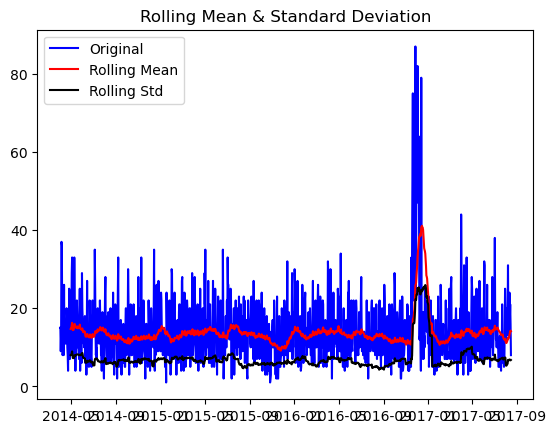

Results of Dickey-Fuller Test:
Test Statistic                -6.706927e+00
p-value                        3.764581e-09
#Lags Used                     2.300000e+01
Number of Observations Used    1.209000e+03
Critical Value (1%)           -3.435770e+00
Critical Value (5%)           -2.863934e+00
Critical Value (10%)          -2.568044e+00
dtype: float64
Is the time series stationary? True


True

In [78]:
# test for stationarity
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):
    window_size = 30
    # Determing rolling statistics
    rolmean = timeseries.rolling(window=window_size, center=False).mean()
    rolstd = timeseries.rolling(window=window_size, center=False).std()

    # Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    # Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pandas.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

    # print the final line yes no whether it's stationary or not
    is_stationary = dftest[1] < 0.05

    print('Is the time series stationary? {0}'.format(is_stationary))
    return is_stationary

test_stationarity(sampledf['unit_sales'])

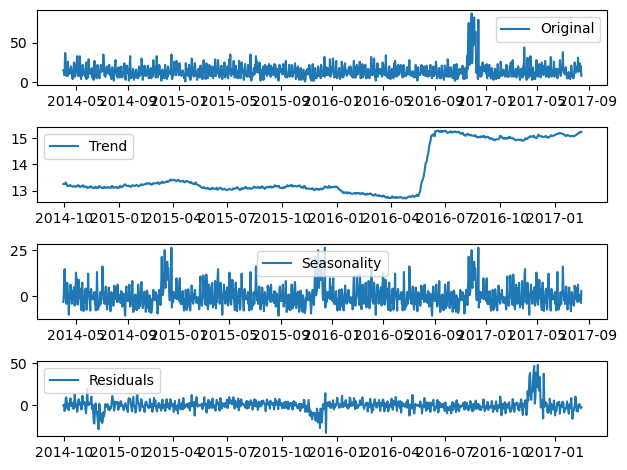

In [79]:
# so the time series is stationary. suggest me what to do next

# decompose the time series
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(sampledf['unit_sales'], period=365)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.subplot(411)
plt.plot(sampledf['unit_sales'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [80]:
sampledf.loc['2016-12-25']

date_jump                     0.0
id                            NaN
onpromotion                 False
unit_sales                   15.0
unit_sales_ma30_lag1    33.966667
                          ...    
moy11                           0
moy12                           1
dow                             6
moy                            12
period                     4after
Name: 2016-12-25 00:00:00, Length: 61, dtype: object

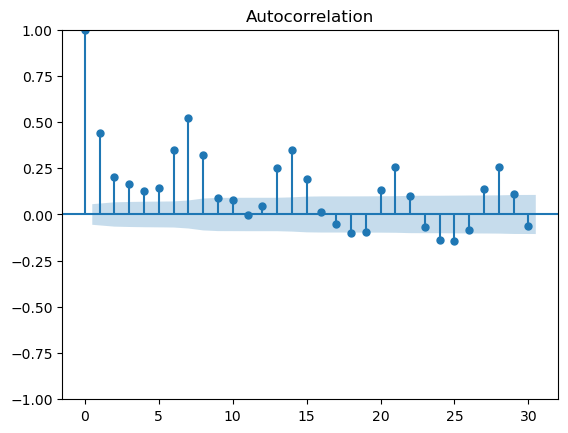

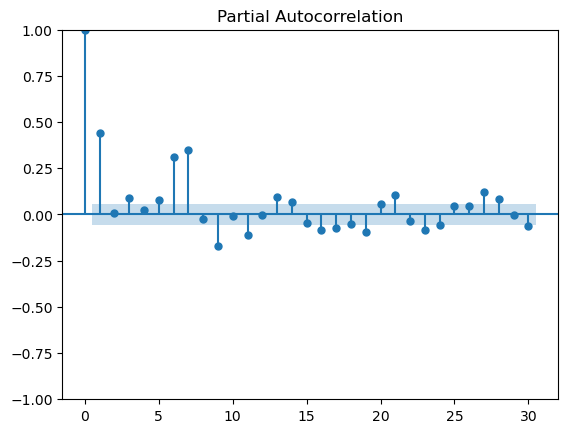

In [81]:
# better way to plot ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf_periods = 30

plot_acf(sampledf['unit_sales'], lags=acf_periods)
plot_pacf(sampledf['unit_sales'], lags=acf_periods)
plt.show()

In [82]:
# pandas should display all rows when print
# import acf
from statsmodels.tsa.stattools import acf, pacf

lag_acf = acf(sampledf['unit_sales'], nlags=acf_periods)
lag_pacf = pacf(sampledf['unit_sales'], nlags=acf_periods, method='ols')


# show as table too
from pandas import DataFrame
acf_table = DataFrame(lag_acf)
acf_table.columns = ['ACF']
acf_table.index.name = 'Lag'
print(acf_table)

# show as table too
pacf_table = DataFrame(lag_pacf)
pacf_table.columns = ['PACF']
pacf_table.index.name = 'Lag'
print(pacf_table)

          ACF
Lag          
0    1.000000
1    0.441991
2    0.203698
3    0.165510
4    0.125779
5    0.140771
6    0.351143
7    0.520355
8    0.322895
9    0.088063
10   0.076993
11  -0.003168
12   0.045364
13   0.250817
14   0.348218
15   0.189904
16   0.015399
17  -0.052743
18  -0.100237
19  -0.092808
20   0.131833
21   0.254428
22   0.098917
23  -0.068773
24  -0.139854
25  -0.142161
26  -0.085931
27   0.140038
28   0.255132
29   0.110589
30  -0.060657
         PACF
Lag          
0    1.000000
1    0.442154
2    0.010214
3    0.089137
4    0.024965
5    0.079889
6    0.313957
7    0.348534
8   -0.022818
9   -0.177264
10  -0.011639
11  -0.108136
12  -0.000189
13   0.094929
14   0.067833
15  -0.047388
16  -0.082327
17  -0.071914
18  -0.047692
19  -0.092400
20   0.056564
21   0.108095
22  -0.034953
23  -0.087213
24  -0.061581
25   0.050794
26   0.051932
27   0.126111
28   0.088511
29  -0.003080
30  -0.066614


## sarimax fit entirely

In [83]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 618 entries, 2014-04-01 to 2015-12-09
Data columns (total 61 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date_jump             617 non-null    float64
 1   id                    616 non-null    float64
 2   onpromotion           618 non-null    object 
 3   unit_sales            618 non-null    float64
 4   unit_sales_ma30_lag1  588 non-null    float64
 5   unit_sales_ma7_lag1   611 non-null    float64
 6   dcoilwtico            618 non-null    float64
 7   onpromotionnum        618 non-null    int64  
 8   dom1                  618 non-null    int64  
 9   dom2                  618 non-null    int64  
 10  dom3                  618 non-null    int64  
 11  dom4                  618 non-null    int64  
 12  dom5                  618 non-null    int64  
 13  dom6                  618 non-null    int64  
 14  dom7                  618 non-null    int64  
 15  dom8

In [84]:
# fit SARIMA(1, 1, 2)(2, 0, 0)6
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train_df['unit_sales'], order=(2, 1, 3), seasonal_order=(1, 0, 0, 7))
results = model.fit(disp=0)
print(results.summary())

/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         unit_sales   No. Observations:                  618
Model:             SARIMAX(2, 1, 3)x(1, 0, [], 7)   Log Likelihood               -1940.336
Date:                            Sun, 09 Jun 2024   AIC                           3894.673
Time:                                    05:35:26   BIC                           3925.647
Sample:                                04-01-2014   HQIC                          3906.715
                                     - 12-09-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5076      0.056    -26.987      0.000      -1.617      -1.398
ar.L2         -0.5931      0.055   

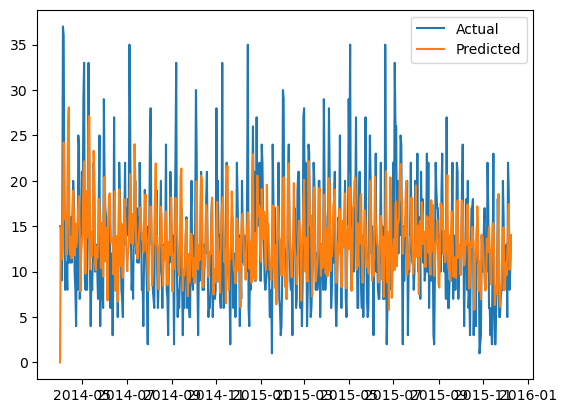

In [85]:
pred = results.get_prediction(start=train_df.index.min(), end=train_df.index.max()).predicted_mean
# get sampledf['unit_sales'] for the same period
actual = sampledf['unit_sales'][train_df.index.min(): train_df.index.max()]

# plot actual vs pred
plt.plot(actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()


/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/

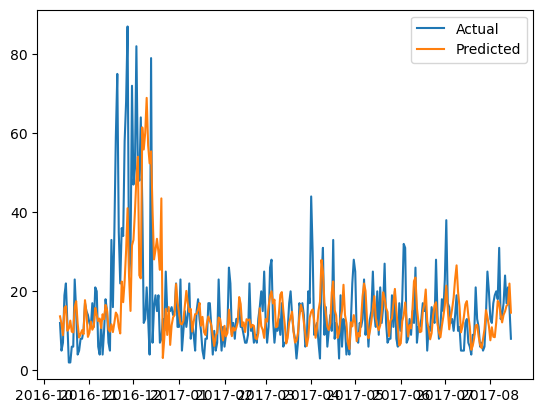

In [137]:
forecast_steps = 7
# forecast 3 times rolling forecast

# traindf is filter sampledf to only up to 2016-06-01
initial_traindf = train_df
train_size = initial_traindf.shape[0]

predictions = []
target_iterations = math.ceil(test_df.shape[0] / forecast_steps)
for i in range(target_iterations):
    traindf = sampledf.iloc[:train_size].copy()
    model = SARIMAX(traindf['unit_sales'], order=(2, 1, 4), seasonal_order=(1, 0, 0, 7), )
    results = model.fit(disp=0)

    pred = results.get_forecast(steps=forecast_steps).predicted_mean
    predictions.append(pred)


    train_size += forecast_steps

raw_sarimax_predict = pandas.concat(predictions)
raw_sarimax_predict = raw_sarimax_predict.loc[raw_sarimax_predict.index <= test_df.index.max()]
# pp

actual = test_df.unit_sales
# actual

plt.plot(actual, label='Actual')
plt.plot(raw_sarimax_predict, label='Predicted')
plt.legend()
plt.show()

RMSE 11.911146479064316
RMSPE 1.170575684967237
MAPE 0.5911058322509705


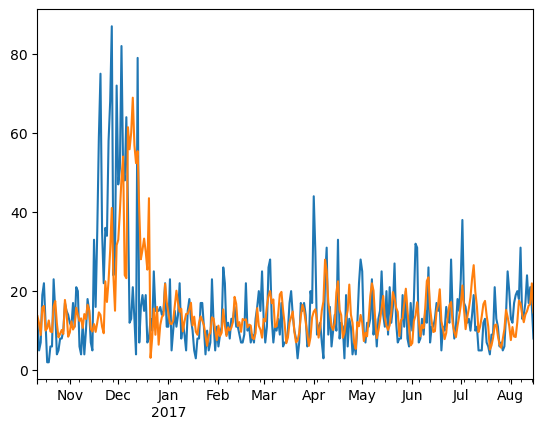

In [138]:
# plot using pandas
actual.plot()
raw_sarimax_predict.plot()



# print RMSE RMSPE MAPE


from math import sqrt
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

def rmspe(y_true, y_pred):
    return sqrt((((y_true - y_pred) / y_true) ** 2).mean())

def mape(y_true, y_pred):
    return (abs(y_true - y_pred) / y_true).mean()

raw_sarimax_rmse = rmse(actual, raw_sarimax_predict)
raw_sarimax_rmspe = rmspe(actual, raw_sarimax_predict)
raw_sarimax_mape = mape(actual, raw_sarimax_predict)

print('RMSE', raw_sarimax_rmse)
print('RMSPE', raw_sarimax_rmspe)
print('MAPE', raw_sarimax_mape)

In [88]:
# RMSE 12.009330123319742
# RMSPE 1.2374272667936637
# MAPE 0.6314216452969972

# PMD AutoARIMA

In [136]:

from pmdarima import auto_arima
model = auto_arima(tuning_train_df.unit_sales, seasonal=True, m=7, stepwise=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=3965.785, Time=0.94 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=4307.820, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=4138.270, Time=0.16 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=4182.970, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=5331.756, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=4154.426, Time=0.59 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=4091.735, Time=0.49 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=inf, Time=1.27 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=3994.536, Time=1.59 sec
 ARIMA(2,0,2)(0,0,0)[7] intercept   : AIC=4242.148, Time=0.15 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=4117.565, Time=1.09 sec
 ARIMA(2,0,2)(2,0,0)[7] intercept   : AIC=4051.631, Time=0.97 sec
 ARIMA(2,0,2)(2,0,2)[7] intercept   : AIC=inf, Time=1.63 sec
 ARIMA(1,0,2)(1,0,1)[7] intercept   : AIC=3951.576, Time=0.82 sec
 ARIMA(1,0,2)(0,0,1)[7] intercept   : AIC=4

In [90]:
sampledf.loc['2016-12-25']

date_jump                     0.0
id                            NaN
onpromotion                 False
unit_sales                   15.0
unit_sales_ma30_lag1    33.966667
                          ...    
moy11                           0
moy12                           1
dow                             6
moy                            12
period                     4after
Name: 2016-12-25 00:00:00, Length: 61, dtype: object

/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/User

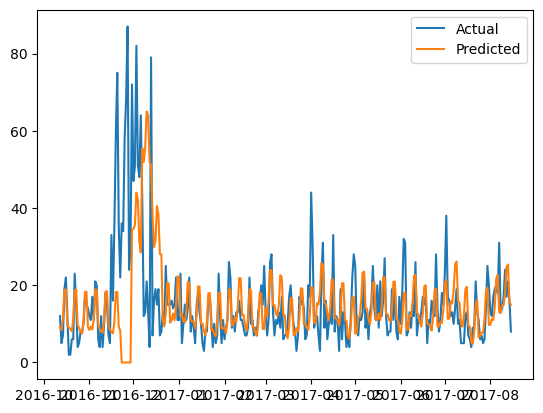

In [135]:
forecast_steps = 7
# forecast 3 times rolling forecast

# traindf is filter sampledf to only up to 2016-06-01
initial_traindf = train_df
train_size = initial_traindf.shape[0]

predictions = []
target_iterations = math.ceil(test_df.shape[0] / forecast_steps)
for i in range(target_iterations):
    traindf = sampledf.iloc[:train_size].copy()
    model = SARIMAX(traindf['unit_sales'], order=(2, 0, 3), seasonal_order=(1, 0, 1, 7), )
    results = model.fit(disp=0)

    pred = results.get_forecast(steps=forecast_steps).predicted_mean
    predictions.append(pred)


    train_size += forecast_steps

tuned_sarimax_predict = pandas.concat(predictions)
tuned_sarimax_predict = tuned_sarimax_predict.loc[tuned_sarimax_predict.index <= test_df.index.max()]
# pp

actual = test_df.unit_sales
# actual

plt.plot(actual, label='Actual')
plt.plot(tuned_sarimax_predict, label='Predicted')
plt.legend()
plt.show()

In [92]:
sampledf.loc['2016-12-25']

date_jump                     0.0
id                            NaN
onpromotion                 False
unit_sales                   15.0
unit_sales_ma30_lag1    33.966667
                          ...    
moy11                           0
moy12                           1
dow                             6
moy                            12
period                     4after
Name: 2016-12-25 00:00:00, Length: 61, dtype: object

RMSE 13.325173479923748
RMSPE 1.0918755765341994
MAPE 0.5572923208213972


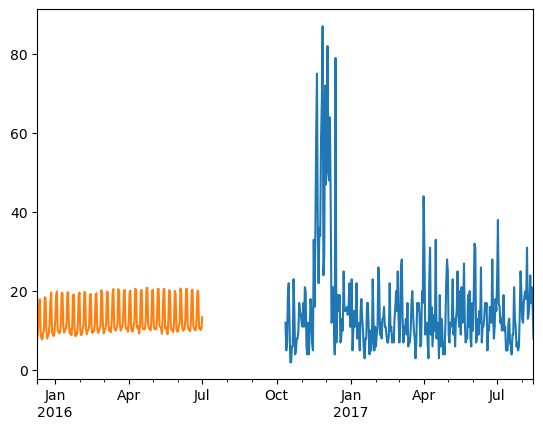

In [140]:
# plot using pandas
actual.plot()
pp.plot()



# print RMSE RMSPE MAPE


from math import sqrt
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

def rmspe(y_true, y_pred):
    return sqrt((((y_true - y_pred) / y_true) ** 2).mean())

def mape(y_true, y_pred):
    return (abs(y_true - y_pred) / y_true).mean()

tuned_arimax_rmse = rmse(actual, tuned_sarimax_predict)
tuned_arimax_rmspe = rmspe(actual, tuned_sarimax_predict)
tuned_arimax_mape = mape(actual, tuned_sarimax_predict)

print('RMSE', tuned_arimax_rmse)
print('RMSPE', tuned_arimax_rmspe)
print('MAPE', tuned_arimax_mape)

In [94]:
sampledf.loc['2016-12-25']

date_jump                     0.0
id                            NaN
onpromotion                 False
unit_sales                   15.0
unit_sales_ma30_lag1    33.966667
                          ...    
moy11                           0
moy12                           1
dow                             6
moy                            12
period                     4after
Name: 2016-12-25 00:00:00, Length: 61, dtype: object

                      model       rmse     rmspe      mape
0                  Ensemble  12.325366  0.830014  0.492011
1           Untuned XGBoost  12.860671  0.723624  0.467767
2             Tuned SARIMAX  13.325173  1.091876  0.557292
3           Untuned SARIMAX  11.911146  1.170576  0.591106
4   Simple Moving Average 7  10.239754  0.989959  0.586735
5  Simple Moving Average 30  12.607940  1.165965  0.693170
6               Random Walk  13.146521  0.911411  0.572004


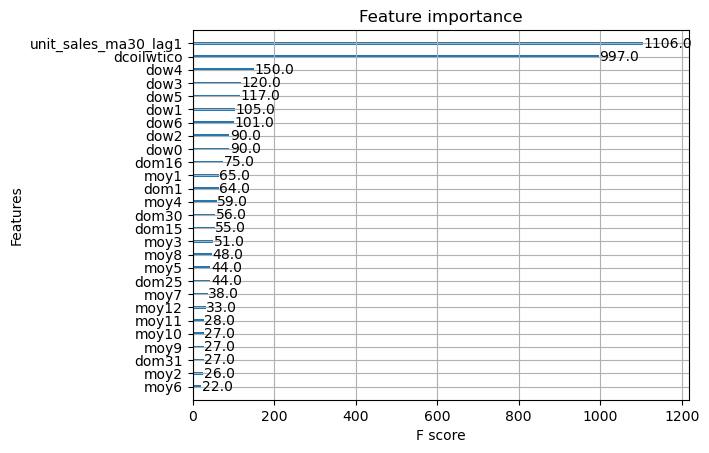

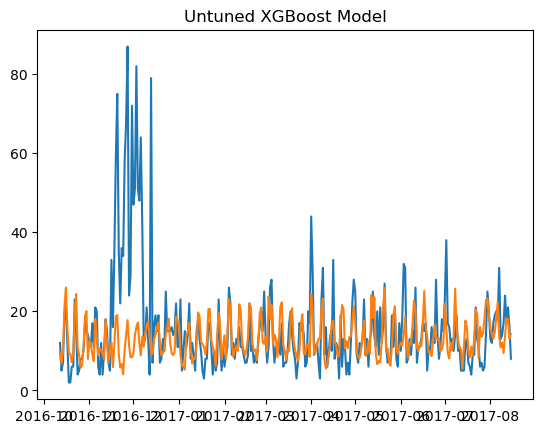

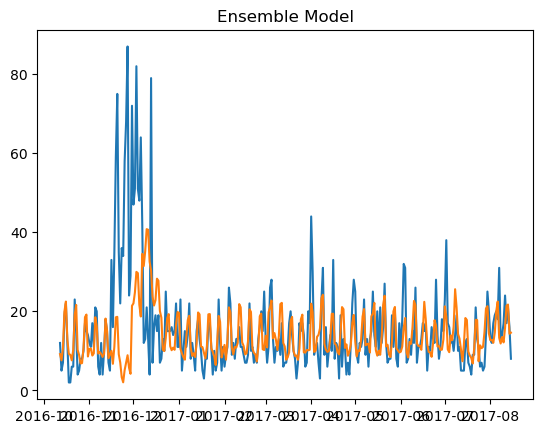

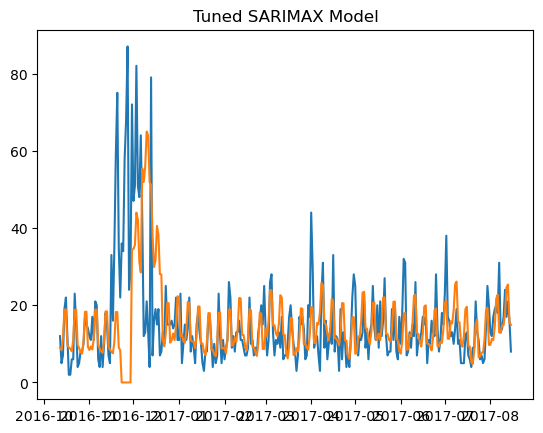

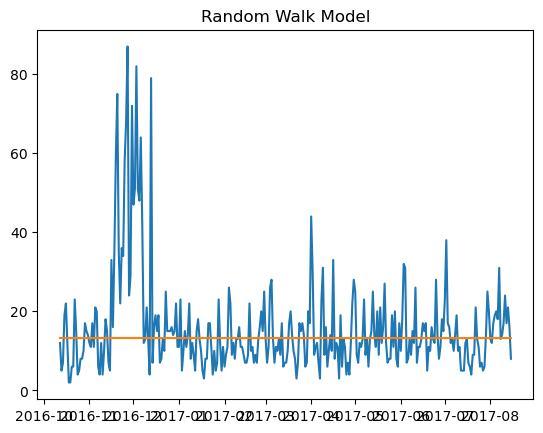

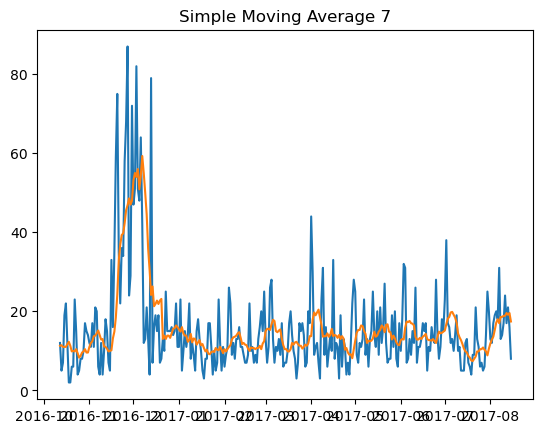

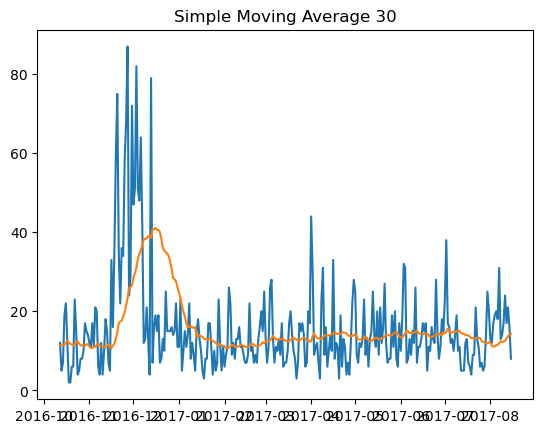

In [154]:
# fit using xgboost
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# drop rows with NaN
# sampledf.dropna(inplace=True)

effective_columns = columns
banned_columns = set([
    # 'dcoilwtico',
    'unit_sales_ma7_lag1',
    # 'unit_sales_ma30_lag1',
])
effective_columns = [column for column in columns if column not in banned_columns]

# split into train and test
X_train = train_df[effective_columns].drop('unit_sales', axis=1)
X_test = test_df[effective_columns].drop('unit_sales', axis=1)
y_train = train_df['unit_sales']
y_test = test_df['unit_sales']


# # scale
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# fit
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

# predict
untuned_xgb_predict_values = model.predict(X_test)
untuned_xgb_predict = pandas.Series(untuned_xgb_predict_values, index=test_df.index)

# evaluate
# rmspe
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))

# print('XGBoost Model')
# print('RMSPE', rmspe(y_test.values, y_pred))
# # rmse
# print('RMSE', np.sqrt(mean_squared_error(y_test, y_pred)))


ensemble_predict = pandas.Series((untuned_xgb_predict + tuned_sarimax_predict) / 2, index=test_df.index)

# print('Simple Moving Average Model')
# print('RMSPE', rmspe(y_test, X_test['unit_sales_ma30_lag1'].values))
# print('RMSE', np.sqrt(mean_squared_error(y_test, X_test['unit_sales_ma30_lag1'])))

# print dataframe rmse rmspe between models. columns = ['model', 'rmse', 'rmspe']

random_walk_prediction = pandas.Series([train_df.unit_sales.mean()] * test_df.shape[0], index=test_df.index)
import numpy as np
results = []
# mape too

results.append(['Ensemble', np.sqrt(mean_squared_error(y_test, ensemble_predict)), rmspe(y_test.values, ensemble_predict), mape(y_test.values, ensemble_predict)] )

results.append(['Untuned XGBoost', np.sqrt(mean_squared_error(y_test, untuned_xgb_predict)), rmspe(y_test.values, untuned_xgb_predict), mape(y_test.values, untuned_xgb_predict)] )
prediction_ma7 = sampledf.loc[X_test.index, 'unit_sales_ma7_lag1']

# result from raw sarimax
results.append(['Tuned SARIMAX', tuned_arimax_rmse, tuned_arimax_rmspe, tuned_arimax_mape])
results.append(['Untuned SARIMAX', raw_sarimax_rmse, raw_sarimax_rmspe, raw_sarimax_mape])


results.append(['Simple Moving Average 7', np.sqrt(mean_squared_error(y_test, prediction_ma7)), rmspe(y_test, prediction_ma7.values), mape(y_test.values, prediction_ma7.values)])
prediction_ma30 = sampledf.loc[X_test.index, 'unit_sales_ma30_lag1']
# results.append(['Simple Moving Average 30', np.sqrt(mean_squared_error(y_test, X_test['unit_sales_ma30_lag1'])), rmspe(y_test, X_test['unit_sales_ma30_lag1'].values)])
results.append(['Simple Moving Average 30', np.sqrt(mean_squared_error(y_test, prediction_ma30)), rmspe(y_test, prediction_ma30.values), mape(y_test.values, prediction_ma30.values)])
results.append(['Random Walk', np.sqrt(mean_squared_error(y_test, random_walk_prediction)), rmspe(y_test, random_walk_prediction.values), mape(y_test.values, random_walk_prediction.values)])
resultsdf = pandas.DataFrame(results, columns=['model', 'rmse', 'rmspe', 'mape'])
print(resultsdf)

# feature importance
import matplotlib.pyplot as plt
xgb.plot_importance(model)
plt.show()


# plot
# add title
import matplotlib.pyplot as plt
plt.title('Untuned XGBoost Model')
plt.plot(y_test)
plt.plot(untuned_xgb_predict)
plt.show()

# plot for ensemble
plt.title('Ensemble Model')
plt.plot(y_test)
plt.plot(ensemble_predict)
plt.show()

# plot for sarimax
plt.title('Tuned SARIMAX Model')
plt.plot(y_test)
plt.plot(tuned_sarimax_predict)
plt.show()

plt.plot(y_test)
plt.title('Random Walk Model')
plt.plot(random_walk_prediction)
plt.show()

# plot
plt.plot(y_test)
plt.title('Simple Moving Average 7')
plt.plot(prediction_ma7)
plt.show()

# plot
plt.plot(y_test)
plt.title('Simple Moving Average 30')
plt.plot(prediction_ma30)
plt.show()






